# **DATASET COLLECTION**

In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"tanughosh","key":"1193299387b750cd03954476acbcca53"}'}

In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [5]:
!kaggle datasets list -s skin

ref                                                                title                                                 size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-----------------------------------------------------------------  ----------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
kmader/skin-cancer-mnist-ham10000                                  Skin Cancer MNIST: HAM10000                     5582914511  2018-09-20 20:36:13.037000         275267       2370  0.7058824        
surajghuwalewala/ham1000-segmentation-and-classification           Skin cancer: HAM10000                           2781385274  2021-05-27 09:08:46.813000          20853        153  0.9411765        
nodoubttome/skin-cancer9-classesisic                               Skin Cancer ISIC                                1647873564  2019-08-26 18:59:21.257000          35585        316  0.75             
pacif

In [6]:
!kaggle datasets download -d kmader/skin-cancer-mnist-ham10000

Dataset URL: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000
License(s): CC-BY-NC-SA-4.0
100% 5.20G/5.20G [01:02<00:00, 88.7MB/s]



In [7]:
!unzip skin-cancer-mnist-ham10000.zip -d dataset

Streaming output truncated to the last 5000 lines.
  inflating: dataset/ham10000_images_part_2/ISIC_0029326.jpg  
  inflating: dataset/ham10000_images_part_2/ISIC_0029327.jpg  
  inflating: dataset/ham10000_images_part_2/ISIC_0029328.jpg  
  inflating: dataset/ham10000_images_part_2/ISIC_0029329.jpg  
  inflating: dataset/ham10000_images_part_2/ISIC_0029330.jpg  
  inflating: dataset/ham10000_images_part_2/ISIC_0029331.jpg  
  inflating: dataset/ham10000_images_part_2/ISIC_0029332.jpg  
  inflating: dataset/ham10000_images_part_2/ISIC_0029333.jpg  
  inflating: dataset/ham10000_images_part_2/ISIC_0029334.jpg  
  inflating: dataset/ham10000_images_part_2/ISIC_0029335.jpg  
  inflating: dataset/ham10000_images_part_2/ISIC_0029336.jpg  
  inflating: dataset/ham10000_images_part_2/ISIC_0029337.jpg  
  inflating: dataset/ham10000_images_part_2/ISIC_0029338.jpg  
  inflating: dataset/ham10000_images_part_2/ISIC_0029339.jpg  
  inflating: dataset/ham10000_images_part_2/ISIC_0029340.jpg  
  in

In [8]:
!ls dataset

ham10000_images_part_1	HAM10000_images_part_2	hmnist_28_28_RGB.csv
HAM10000_images_part_1	HAM10000_metadata.csv	hmnist_8_8_L.csv
ham10000_images_part_2	hmnist_28_28_L.csv	hmnist_8_8_RGB.csv


# **Import Libraries**

In [9]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


# **Check Dataset Structure**

In [11]:
!ls dataset/HAM10000_images_part_1 | head

ISIC_0024306.jpg
ISIC_0024307.jpg
ISIC_0024308.jpg
ISIC_0024309.jpg
ISIC_0024310.jpg
ISIC_0024311.jpg
ISIC_0024312.jpg
ISIC_0024313.jpg
ISIC_0024314.jpg
ISIC_0024315.jpg


In [12]:
!ls dataset/HAM10000_images_part_2 | head

ISIC_0029306.jpg
ISIC_0029307.jpg
ISIC_0029308.jpg
ISIC_0029309.jpg
ISIC_0029310.jpg
ISIC_0029311.jpg
ISIC_0029312.jpg
ISIC_0029313.jpg
ISIC_0029314.jpg
ISIC_0029315.jpg


# **Load Metadata**

In [13]:
metadata = pd.read_csv("dataset/HAM10000_metadata.csv")

metadata.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


# **Explore the Dataset**

In [14]:
print(metadata.shape)

metadata.info()

metadata.describe()

metadata.head()

(10015, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  object 
 1   image_id      10015 non-null  object 
 2   dx            10015 non-null  object 
 3   dx_type       10015 non-null  object 
 4   age           9958 non-null   float64
 5   sex           10015 non-null  object 
 6   localization  10015 non-null  object 
dtypes: float64(1), object(6)
memory usage: 547.8+ KB


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


# **Count Images per Disease**

In [15]:
metadata['dx'].value_counts()

,count
dx,
nv,6705
mel,1113
bkl,1099
bcc,514
akiec,327
vasc,142
df,115


| Code  | Disease              |
| ----- | -------------------- |
| nv    | Melanocytic Nevi     |
| mel   | Melanoma             |
| bkl   | Benign Keratosis     |
| bcc   | Basal Cell Carcinoma |
| akiec | Actinic Keratosis    |
| vasc  | Vascular Lesion      |
| df    | Dermatofibroma       |


# **Visualize Class Distribution**

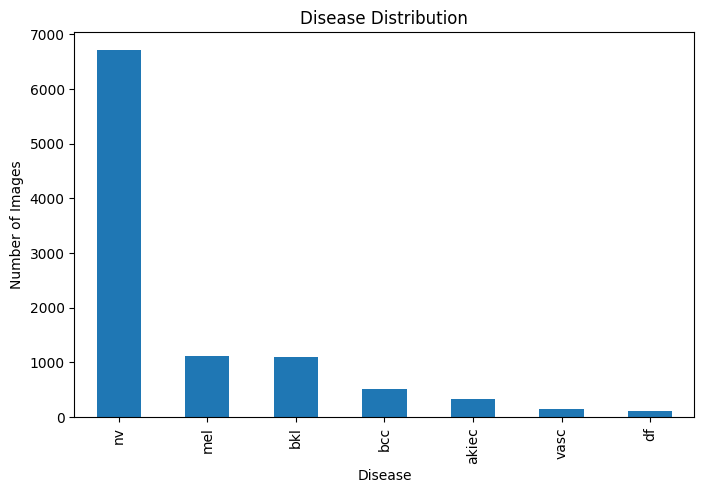

In [16]:
metadata['dx'].value_counts().plot(kind='bar', figsize=(8,5))
plt.title("Disease Distribution")
plt.xlabel("Disease")
plt.ylabel("Number of Images")
plt.show()

What we learned from the EDA
Dataset size: 10,015 images
Number of classes: 7
Class imbalance: Very high
nv has 6705 images (~ 67%)
df has only 115 images (~ 1%)

This imbalance is important because a model could simply predict nv most of the time and still get high accuracy. Later, we'll address this using class weights and data augmentation.

# **Create Image Path Dictionary**

In [18]:
import os
from glob import glob

image_path = {os.path.splitext(os.path.basename(x))[0]: x
              for x in glob(os.path.join("dataset", "*", "*.jpg"))}

print("Total Images:", len(image_path))

Total Images: 10015


# **Add Image Paths to Metadata**

In [19]:
metadata["path"] = metadata["image_id"].map(image_path.get)

metadata.head()

#Now every row knows where its image is stored.

,lesion_id,image_id,dx,dx_type,age,sex,localization,path
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,dataset/HAM10000_images_part_1/ISIC_0027419.jpg
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,dataset/HAM10000_images_part_1/ISIC_0025030.jpg
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,dataset/HAM10000_images_part_1/ISIC_0026769.jpg
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,dataset/HAM10000_images_part_1/ISIC_0025661.jpg
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,dataset/ham10000_images_part_2/ISIC_0031633.jpg


# **Decode Disease Codes**

In [20]:
#Instead of using nv,mel,bkl,...we will use proper names

lesion_type = {
    'nv':'Melanocytic Nevi',
    'mel':'Melanoma',
    'bkl':'Benign Keratosis',
    'bcc':'Basal Cell Carcinoma',
    'akiec':'Actinic Keratosis',
    'vasc':'Vascular Lesion',
    'df':'Dermatofibroma'
}

metadata["disease"] = metadata["dx"].map(lesion_type)

metadata.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,path,disease
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,dataset/HAM10000_images_part_1/ISIC_0027419.jpg,Benign Keratosis
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,dataset/HAM10000_images_part_1/ISIC_0025030.jpg,Benign Keratosis
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,dataset/HAM10000_images_part_1/ISIC_0026769.jpg,Benign Keratosis
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,dataset/HAM10000_images_part_1/ISIC_0025661.jpg,Benign Keratosis
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,dataset/ham10000_images_part_2/ISIC_0031633.jpg,Benign Keratosis


# **Check Missing Values**

In [21]:
metadata.isnull().sum()

,0
lesion_id,0
image_id,0
dx,0
dx_type,0
age,57
sex,0
localization,0
path,0
disease,0


# **Fill Missing Age**

In [22]:
metadata["age"].isnull().sum()

np.int64(57)

In [23]:
metadata["age"] = metadata["age"].fillna(metadata["age"].median())

In [24]:
metadata.isnull().sum()

,0
lesion_id,0
image_id,0
dx,0
dx_type,0
age,0
sex,0
localization,0
path,0
disease,0


# **Check Duplicate Images**

In [25]:
metadata["image_id"].duplicated().sum()

np.int64(0)

# **Check Duplicate Lesions**

In [26]:
metadata["lesion_id"].duplicated().sum()

np.int64(2545)

You'll notice there are many duplicates.

Why?

Because one lesion may have been photographed from multiple angles.

This is normal.

# **Display Random Images**

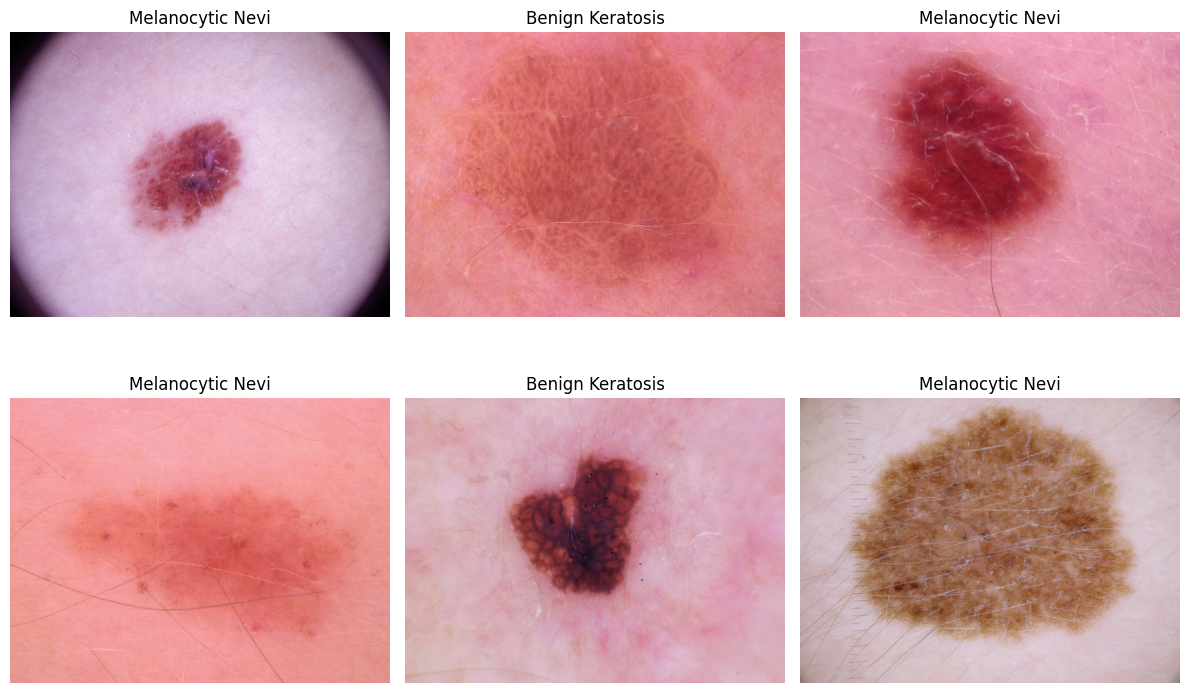

In [27]:
import matplotlib.pyplot as plt
from PIL import Image

fig, axes = plt.subplots(2,3, figsize=(12,8))

sample = metadata.sample(6)

for ax, (_, row) in zip(axes.flatten(), sample.iterrows()):
    img = Image.open(row["path"])
    ax.imshow(img)
    ax.set_title(row["disease"])
    ax.axis("off")

plt.tight_layout()
plt.show()

# **Image Size Analysis**

In [28]:
sizes = []

for path in metadata["path"][:500]:
    img = Image.open(path)
    sizes.append(img.size)

sizes[:10]

[(600, 450),
 (600, 450),
 (600, 450),
 (600, 450),
 (600, 450),
 (600, 450),
 (600, 450),
 (600, 450),
 (600, 450),
 (600, 450)]

In [29]:
#Now check the most common size:
from collections import Counter

Counter(sizes).most_common(10)

[((600, 450), 500)]

# **Resize Test**

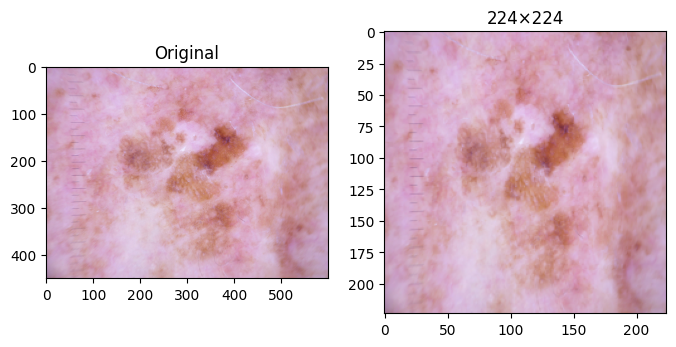

In [30]:
img = Image.open(metadata["path"][0])

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(img.resize((224,224)))
plt.title("224×224")

plt.show()

# **Label Encoding**

Our target variable dx contains strings: <br>
nv<br>
mel<br>
bcc<br>
bkl<br>
akiec<br>
vasc<br>
df

Neural networks can't train on strings, so we'll convert them to integers.

In [31]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

metadata["label"] = label_encoder.fit_transform(metadata["dx"])

metadata[["dx","label"]].head()

,dx,label
0,bkl,2
1,bkl,2
2,bkl,2
3,bkl,2
4,bkl,2


In [32]:
mapping = dict(zip(label_encoder.classes_,
                   label_encoder.transform(label_encoder.classes_)))

print(mapping)

{'akiec': np.int64(0), 'bcc': np.int64(1), 'bkl': np.int64(2), 'df': np.int64(3), 'mel': np.int64(4), 'nv': np.int64(5), 'vasc': np.int64(6)}


# **Save Label Encoder (.pkl)**

In [33]:
import pickle
import os

os.makedirs("saved_objects", exist_ok=True)

with open("saved_objects/label_encoder.pkl","wb") as f:
    pickle.dump(label_encoder,f)

print("Saved successfully")

Saved successfully


# **Train-Test Split**

In [34]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    metadata,
    test_size=0.30,
    stratify=metadata["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

print(train_df.shape)
print(val_df.shape)
print(test_df.shape)

(7010, 10)
(1502, 10)
(1503, 10)


This is one of the most important steps.

We'll split the dataset into:

70% Training<br>
15% Validation<br>
15% Testing

Use a stratified split so each class keeps the same proportion.

# **Verify Split**

In [35]:
print(train_df["dx"].value_counts(normalize=True))
print()

print(val_df["dx"].value_counts(normalize=True))
print()

print(test_df["dx"].value_counts(normalize=True))

dx
nv       0.669472
mel      0.111127
bkl      0.109700
bcc      0.051355
akiec    0.032668
vasc     0.014123
df       0.011555
Name: proportion, dtype: float64

dx
nv       0.669774
mel      0.111185
bkl      0.109854
bcc      0.051265
akiec    0.032623
vasc     0.013981
df       0.011318
Name: proportion, dtype: float64

dx
nv       0.669328
mel      0.111111
bkl      0.109780
bcc      0.051231
akiec    0.032601
vasc     0.014637
df       0.011311
Name: proportion, dtype: float64


Stratified sampling was successfully applied. The class distribution is preserved across the training, validation, and test sets, ensuring that each subset represents the original dataset. This helps prevent bias during training and provides reliable model evaluation.

# **Save Processed DataFrames (.pkl)**

In [36]:
with open("saved_objects/train_df.pkl","wb") as f:
    pickle.dump(train_df,f)

with open("saved_objects/val_df.pkl","wb") as f:
    pickle.dump(val_df,f)

with open("saved_objects/test_df.pkl","wb") as f:
    pickle.dump(test_df,f)

print("Train/Validation/Test saved")

Train/Validation/Test saved


# **Compute Class Weights**

The dataset is highly imbalanced.

This is where we handle it.

Instead of ignoring the imbalance, we'll compute class weights now and use them during training.

In [37]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_df["label"]),
    y=train_df["label"]
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: np.float64(4.37305053025577), 1: np.float64(2.7817460317460316), 2: np.float64(1.3022478172023035), 3: np.float64(12.36331569664903), 4: np.float64(1.285530900421786), 5: np.float64(0.21338772031292808), 6: np.float64(10.115440115440116)}


# **Save Class Weights (.pkl)**

In [38]:
with open("saved_objects/class_weights.pkl","wb") as f:
    pickle.dump(class_weights,f)

print("Class weights saved")

Class weights saved
